In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import sklearn
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, TargetEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

print(pd.__version__, sklearn.__version__)

2.2.2 1.6.1


In [ ]:
df = pd.read_csv('data.csv')

In [ ]:
df.describe().round(2)

,Price,Minutes to metro,Number of rooms,Area,Living area,Kitchen area,Floor,Number of floors
count,2.267600e+04,22676.00,22676.00,22676.00,22676.00,22676.00,22676.00,22676.00
mean,3.612132e+07,11.89,2.04,71.97,38.52,12.59,9.19,16.56
std,8.282561e+07,6.20,1.52,68.37,38.12,7.73,7.55,9.78
min,1.150000e+06,0.00,0.00,6.00,2.00,1.00,1.00,1.00
25%,7.068116e+06,7.00,1.00,37.40,17.60,8.60,4.00,11.00
50%,1.134320e+07,11.00,2.00,53.30,28.50,10.60,8.00,16.00
75%,2.479925e+07,15.00,3.00,77.14,43.20,14.50,13.00,20.00
max,2.455020e+09,60.00,12.00,1117.00,566.80,122.00,92.00,97.00


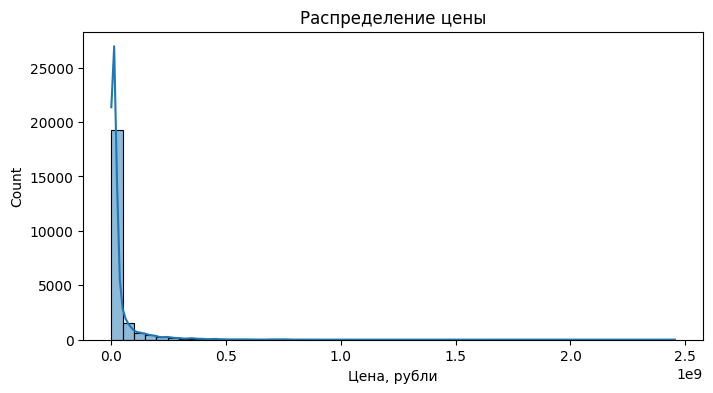

In [ ]:
# Цена — гистограмма
plt.figure(figsize=(8, 4))
sns.histplot(df['Price'], bins=50, kde=True)
plt.title('Распределение цены')
plt.xlabel('Цена, рубли')
plt.show()

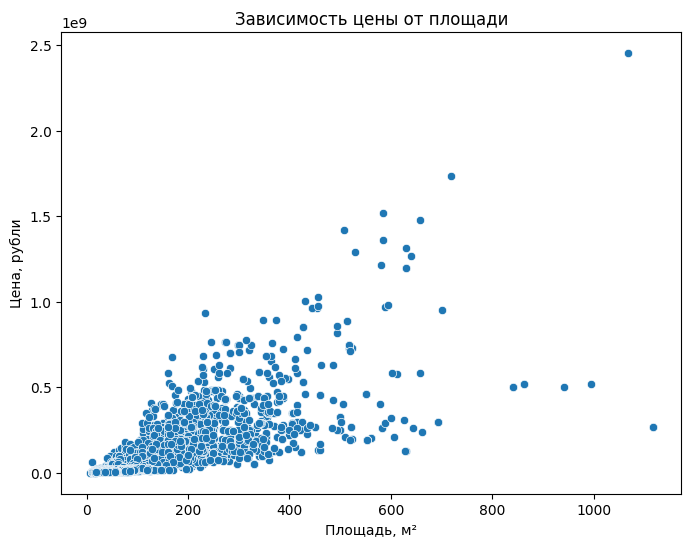

In [ ]:
# Цена vs Площадь (scatter)
plt.figure(figsize=(8, 6))
sns.scatterplot(x='Area', y='Price', data=df)
plt.title('Зависимость цены от площади')
plt.xlabel('Площадь, м²')
plt.ylabel('Цена, рубли')
plt.show()

In [ ]:
# ---------------------------------------------------------
# 1. Загрузка и базовая очистка
# ---------------------------------------------------------
df = pd.read_csv('data.csv')
df.columns = ['price', 'building_type', 'metro_station', 'minutes_to_metro', 'location',
              'rooms', 'total_area', 'living_area', 'kitchen_area', 'floor',
              'building_floors', 'renovation']
df.head()

,price,building_type,metro_station,minutes_to_metro,location,rooms,total_area,living_area,kitchen_area,floor,building_floors,renovation
0,6300000.0,Secondary,Опалиха,6.0,Moscow region,1.0,30.6,11.1,8.5,25.0,25,Cosmetic
1,9000000.0,Secondary,Павшино,2.0,Moscow region,1.0,49.2,20.0,10.0,6.0,15,European-style renovation
2,11090000.0,Secondary,Мякинино,14.0,Moscow region,1.0,44.7,16.2,13.1,10.0,25,Cosmetic
3,8300000.0,Secondary,Строгино,8.0,Moscow region,1.0,35.1,16.0,11.0,12.0,33,European-style renovation
4,6450000.0,Secondary,Опалиха,6.0,Moscow region,1.0,37.7,15.2,4.0,5.0,5,Without renovation


In [ ]:
df[df['location'] != 'Moscow region'].metro_station.value_counts()

,count
metro_station,
Депо,1646
Братиславская,1155
Каширская,295
ЗИЛ,205
Варшавская,199
...,...
Сколково,1
Трубная,1
Алма-Атинская,1


In [ ]:

# удаляем дубликаты: кол-во строк уменьшилось с 22к до 20к
df = df.drop_duplicates().reset_index(drop=True)
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20841 entries, 0 to 20840
Data columns (total 12 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   price             20841 non-null  float64
 1   building_type     20841 non-null  object 
 2   metro_station     20841 non-null  object 
 3   minutes_to_metro  20841 non-null  float64
 4   location          20841 non-null  object 
 5   rooms             20841 non-null  float64
 6   total_area        20841 non-null  float64
 7   living_area       20841 non-null  float64
 8   kitchen_area      20841 non-null  float64
 9   floor             20841 non-null  float64
 10  building_floors   20841 non-null  int64  
 11  renovation        20841 non-null  object 
dtypes: float64(7), int64(1), object(4)
memory usage: 1.9+ MB


In [ ]:
# Цены сильно скошены → логарифмируем целевую переменную
df['log_price'] = np.log1p(df['price'])

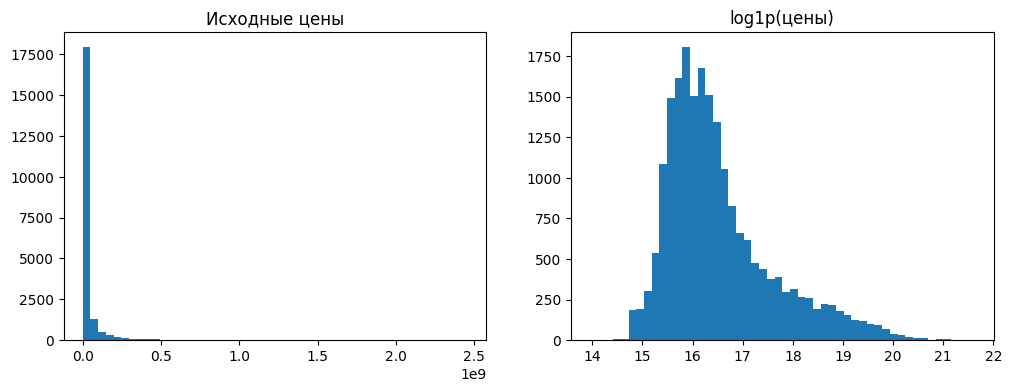

In [ ]:
# насколько логарифм «выпрямил» распределение
import matplotlib.pyplot as plt
import numpy as np

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(df['price'], bins=50)
axes[0].set_title('Исходные цены')
axes[1].hist(np.log1p(df['price']), bins=50)
axes[1].set_title('log1p(цены)')
plt.show()

In [ ]:
# Добавляем дополнительные свойства
df['price_per_m2'] = df['price'] / df['total_area'].clip(lower=1)
df['area_ratio'] = df['living_area'] / df['total_area'].clip(lower=1)
df['is_moscow'] = (df['location'] == 'Moscow').astype(int)

In [ ]:
# отмечаем, что в distict (район) - более 500 уникальных значений. Поэтому для
# преобразования в число не подойдет OneHotEncoder - много колонок добавится.
# LabelEncoder() не используем, т.к. он может создать ненужную связь между
# значениям.

df.nunique()

,0
price,9979
building_type,2
metro_station,547
minutes_to_metro,56
location,2
rooms,12
total_area,3017
living_area,1302
kitchen_area,481
floor,72


In [ ]:
X = df.drop(columns=['price', 'log_price'])
y = df['log_price']

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [ ]:
# ---------------------------------------------------------
# 2. Настройка препроцессинга
# ---------------------------------------------------------
cat_cols = ['building_type', 'metro_station', 'renovation']
num_cols = ['minutes_to_metro', 'rooms', 'total_area', 'living_area',
            'kitchen_area', 'floor', 'building_floors',
            'price_per_m2', 'area_ratio', 'is_moscow']

#
# TargetEncoder корректно работает с high-cardinality признаками (районы)
# и предотвращает data leakage через cross-validation (cv=5)
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), num_cols),
        ('cat', TargetEncoder(target_type='continuous', cv=5), cat_cols)
    ],
    remainder='drop'
)

In [ ]:
# ---------------------------------------------------------
# 3. Функция обучения и оценки
# ---------------------------------------------------------
def train_and_evaluate(model, name):
    pipeline = Pipeline(steps=[
        ('preprocessor', preprocessor),
        ('model', model)
    ])

    pipeline.fit(X_train, y_train)
    pred_log = pipeline.predict(X_test)

    # Возвращаем метрики к исходной шкале (рубли)
    pred_price = np.expm1(pred_log)
    true_price = np.expm1(y_test)

    mae  = mean_absolute_error(true_price, pred_price)
    rmse = np.sqrt(mean_squared_error(true_price, pred_price))
    r2   = r2_score(true_price, pred_price)

    print(f"\n📊 {name}")
    print(f"   MAE:  {mae:>12,.0f} ₽")
    print(f"   RMSE: {rmse:>12,.0f} ₽")
    print(f"   R²:   {r2:.4f}")
    return pipeline

In [ ]:
# ---------------------------------------------------------
# 4. Запуск трёх моделей
# ---------------------------------------------------------
print("="*50)
print("Базовые модели прогнозирования стоимости жилья")
print("="*50)

lin_reg = train_and_evaluate(LinearRegression(), "Linear Regression")
dt_reg  = train_and_evaluate(DecisionTreeRegressor(max_depth=8, random_state=42), "Decision Tree")
rf_reg  = train_and_evaluate(RandomForestRegressor(n_estimators=200, max_depth=12, random_state=42, n_jobs=-1), "Random Forest")

Базовые модели прогнозирования стоимости жилья

📊 Linear Regression
   MAE:    11,745,658 ₽
   RMSE:   90,728,612 ₽
   R²:   -0.4853

📊 Decision Tree
   MAE:     2,617,294 ₽
   RMSE:   12,809,932 ₽
   R²:   0.9704

📊 Random Forest
   MAE:       822,346 ₽
   RMSE:    7,625,292 ₽
   R²:   0.9895
